# Trial Comparison
Cross-run comparison over the **test + val** trials (maps `Town04` + `Town10HD`).

For each trial, this notebook loads the latest `runs/<timestamp>_<prefix>/` for each of the six recognised prefixes:

| Prefix     | Source                                                |
|------------|--------------------------------------------------------|
| `base`     | `trial_batch_runner.ipynb` (full-speed, both models post-hoc) |
| `slow`     | `trial_slow_batch_runner.ipynb` (`SPEED_FACTOR=0.75`)  |
| `half_slow`| Slow runner with `SPEED_FACTOR=0.5` (if produced)       |
| `very_slow`| Slow runner with `SPEED_FACTOR≤0.5` (if produced)      |
| `e2e`      | `trial_models_batch_runner.ipynb` E2E pass             |
| `composed` | `trial_models_batch_runner.ipynb` Composed pass        |

Any prefix that doesn't have a run yet is left blank in the visual grids and reported as `n/a` in the tables.

Outputs land at `MIREIA/trials/<trial>/comparison/`:
- `metrics.csv` — per-prefix metrics for that trial
- `route_by_risk.png` / `route_by_speed.png` — 2×3 route maps
- `comparison_video.mp4` — 2×3 animated comparison

A combined `comparison_summary.csv` is also written next to `PATH_TO_TRIALS`.

## 1 — Imports

In [ ]:
import csv
import json
from pathlib import Path

from IPython.display import Video, display

from MIREIA.analysis.trial_comparison import (
    RUN_GRID_LAYOUT,
    RUN_PREFIXES,
    TEST_VAL_MAP_NAMES,
    aggregate_by_prefix,
    compute_run_metrics,
    compute_trial_metrics_table,
    discover_trial_runs,
    is_test_or_val_trial,
    render_comparison_video,
    render_efficiency_barplot,
    render_route_grid,
)
from MIREIA.config import Config

print('Imports ready.')
print(f'Test+val maps: {TEST_VAL_MAP_NAMES}')
print(f'Prefixes:      {RUN_PREFIXES}')

## 2 — Discover Test+Val Trials
Lists every saved `TrialDefinition` whose map is `Town04` or `Town10HD`. Adjust `INCLUDE_REGEX` / `EXCLUDE_TRIALS` to narrow the comparison.

In [2]:
import re

trials_root = Path(Config.PATH_TO_TRIALS)
all_trial_dirs = sorted(p.parent for p in trials_root.glob('*/trial.json') if p.is_file())

INCLUDE_REGEX: str | None = None       # e.g. r'Town10HD' to only keep Town10HD
EXCLUDE_TRIALS: list[str] = []         # exact trial names to skip

selected_trial_dirs: list[Path] = []
for tdir in all_trial_dirs:
    trial_meta = json.loads((tdir / 'trial.json').read_text(encoding='utf-8'))
    map_name = str(trial_meta.get('map_name', ''))
    if not is_test_or_val_trial(tdir.name, map_name=map_name):
        continue
    if INCLUDE_REGEX and not re.search(INCLUDE_REGEX, tdir.name):
        continue
    if tdir.name in EXCLUDE_TRIALS:
        continue
    selected_trial_dirs.append(tdir)

print(f'All trials: {len(all_trial_dirs)};  test+val selected: {len(selected_trial_dirs)}')
for tdir in selected_trial_dirs:
    print(f'  - {tdir.name}')

All trials: 20;  test+val selected: 10
  - auto_17C_WetNoon_Town10HD_HighVol
  - auto_17D_WetNoon_Town10HD_LowVol
  - auto_18C_MidRainyNoon_Town10HD_HighVol
  - auto_18D_MidRainyNoon_Town10HD_LowVol
  - auto_19C_CloudySunset_Town10HD_HighVol
  - auto_19D_CloudySunset_Town10HD_LowVol
  - auto_20C_SoftRainSunset_Town10HD_HighVol
  - auto_20D_SoftRainSunset_Town10HD_LowVol
  - auto_21C_WetNoon_Town10HD_HighVol_NoFog_Night
  - auto_21D_HardRainNoon_Town10HD_LowVol_NoFog_Night


## 3 — Load Runs Per Trial
`discover_trial_runs` walks `runs/<timestamp>_<prefix>/` for every recognised prefix and returns the **latest** one (sorted by folder name, which starts with `YYYYMMDD_HHMMSS_`). Missing prefixes come back as `None` so the rest of the pipeline can leave them blank.

In [3]:
runs_by_trial: dict[str, dict] = {}

for tdir in selected_trial_dirs:
    runs = discover_trial_runs(tdir)
    runs_by_trial[tdir.name] = runs
    available = [p for p, rd in runs.items() if rd is not None]
    missing   = [p for p, rd in runs.items() if rd is None]
    print(f'{tdir.name:55s} have={available}  missing={missing}')

auto_17C_WetNoon_Town10HD_HighVol                       have=['base', 'half_slow', 'slow', 'very_slow']  missing=['e2e', 'composed']
auto_17D_WetNoon_Town10HD_LowVol                        have=['base', 'half_slow', 'slow', 'very_slow']  missing=['e2e', 'composed']
auto_18C_MidRainyNoon_Town10HD_HighVol                  have=['base', 'half_slow', 'slow', 'very_slow']  missing=['e2e', 'composed']
auto_18D_MidRainyNoon_Town10HD_LowVol                   have=['base', 'half_slow', 'slow', 'very_slow']  missing=['e2e', 'composed']
auto_19C_CloudySunset_Town10HD_HighVol                  have=['base', 'half_slow', 'slow', 'very_slow']  missing=['e2e', 'composed']
auto_19D_CloudySunset_Town10HD_LowVol                   have=['base', 'half_slow', 'slow', 'very_slow']  missing=['e2e', 'composed']
auto_20C_SoftRainSunset_Town10HD_HighVol                have=['base', 'half_slow', 'slow', 'very_slow']  missing=['e2e', 'composed']
auto_20D_SoftRainSunset_Town10HD_LowVol                 have=['base',

## 4 — Data Summary Tables
Two tables:

1. **Per-trial / per-prefix** — every (trial, prefix) row with full metrics. Also written to `<trial>/comparison/metrics.csv` and a combined `<PATH_TO_TRIALS>/comparison_summary.csv`.
2. **Cross-trial mean/median per prefix** — aggregate over the test+val set so you can compare prefixes head-to-head.

Metric definitions:

- `total_distance_m`  — sum of per-segment ego XY displacements.
- `total_sim_time_s`  — `n_frames * fixed_delta * image_stride`.
- `risk_per_meter`    — `∫ risk(s) ds / total_distance` (trapezoidal in **distance**, not time — lets you compare runs of unequal duration).
- `risk_auc`          — same risk integrated in **time** (km/h·s units), kept for reference.
- `avg_speed_kmh` / `max_speed_kmh` / `speed_std_kmh` — from `ego.speed * 3.6`.

In [4]:
PER_TRIAL_CSV_COLS = (
    'trial', 'prefix', 'available', 'n_frames',
    'total_distance_m', 'total_sim_time_s',
    'avg_speed_kmh', 'max_speed_kmh', 'speed_std_kmh',
    'risk_auc', 'risk_per_meter', 'mean_risk', 'max_risk',
)

rows = compute_trial_metrics_table(runs_by_trial)

# Per-trial pretty print + per-trial CSV.
for tdir in selected_trial_dirs:
    trial_rows = [r for r in rows if r['trial'] == tdir.name]
    print()
    print(f'=== {tdir.name} ===')
    print(f"  {'prefix':10s} {'n_frames':>8s} {'dist_m':>9s} {'time_s':>8s} {'avg_kmh':>8s} {'max_kmh':>8s} {'risk_auc':>9s} {'risk/m':>9s}")
    for r in trial_rows:
        marker = '  ' if r['available'] else '· '
        print(
            f"{marker}{r['prefix']:10s} {r['n_frames']:>8d} {r['total_distance_m']:>9.1f} "
            f"{r['total_sim_time_s']:>8.1f} {r['avg_speed_kmh']:>8.2f} {r['max_speed_kmh']:>8.2f} "
            f"{r['risk_auc']:>9.3f} {r['risk_per_meter']:>9.4f}"
        )

    cmp_dir = tdir / 'comparison'
    cmp_dir.mkdir(parents=True, exist_ok=True)
    with open(cmp_dir / 'metrics.csv', 'w', encoding='utf-8', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=PER_TRIAL_CSV_COLS)
        writer.writeheader()
        for r in trial_rows:
            writer.writerow({k: r.get(k, '') for k in PER_TRIAL_CSV_COLS})

# Combined CSV across every (trial, prefix).
combined_csv = trials_root / 'comparison_summary.csv'
with open(combined_csv, 'w', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=PER_TRIAL_CSV_COLS)
    writer.writeheader()
    for r in rows:
        writer.writerow({k: r.get(k, '') for k in PER_TRIAL_CSV_COLS})
print(f'\nWrote combined CSV: {combined_csv}')

# Cross-trial aggregation per prefix (mean + median across available runs).
print()
print('=== Cross-trial aggregation per prefix (test+val) ===')
agg = aggregate_by_prefix(rows)
print(f"  {'prefix':10s} {'n':>3s} {'dist_m̄':>10s} {'time_s̄':>9s} {'v̄_kmh':>8s} {'risk/m̄':>10s} {'risk/m ̃':>10s}")
for a in agg:
    print(
        f"  {a['prefix']:10s} {a['n_runs']:>3d} "
        f"{a['total_distance_m_mean']:>10.1f} {a['total_sim_time_s_mean']:>9.1f} "
        f"{a['avg_speed_kmh_mean']:>8.2f} {a['risk_per_meter_mean']:>10.4f} {a['risk_per_meter_median']:>10.4f}"
    )


=== auto_17C_WetNoon_Town10HD_HighVol ===
  prefix     n_frames    dist_m   time_s  avg_kmh  max_kmh  risk_auc    risk/m
  base            179     160.8     44.8     9.28    27.34   105.706    3.7164
· e2e               0       0.0      0.0     0.00     0.00     0.000    0.0000
· composed          0       0.0      0.0     0.00     0.00     0.000    0.0000
  half_slow       250     160.0     62.5     9.25    26.33   151.172    3.6555
  slow            250     159.9     62.5     9.26    22.50   151.370    3.4831
  very_slow       274     160.4     68.5     8.45    14.34   154.231    2.8305

=== auto_17D_WetNoon_Town10HD_LowVol ===
  prefix     n_frames    dist_m   time_s  avg_kmh  max_kmh  risk_auc    risk/m
  base            457     422.2    114.2     9.53    27.56   265.783    3.6661
· e2e               0       0.0      0.0     0.00     0.00     0.000    0.0000
· composed          0       0.0      0.0     0.00     0.00     0.000    0.0000
  half_slow       644     423.0    161.0     9

## 5 — Route Plots Colored by Ground-Truth Risk
One static 2×3 figure per trial. Each panel draws the ego `(x, y)` trajectory colored by `ground_truth_risk` at that point along the route; brighter / yellower segments = higher risk. Missing prefixes show `(no run)` and stay blank. Saved to `<trial>/comparison/route_by_risk.png`.

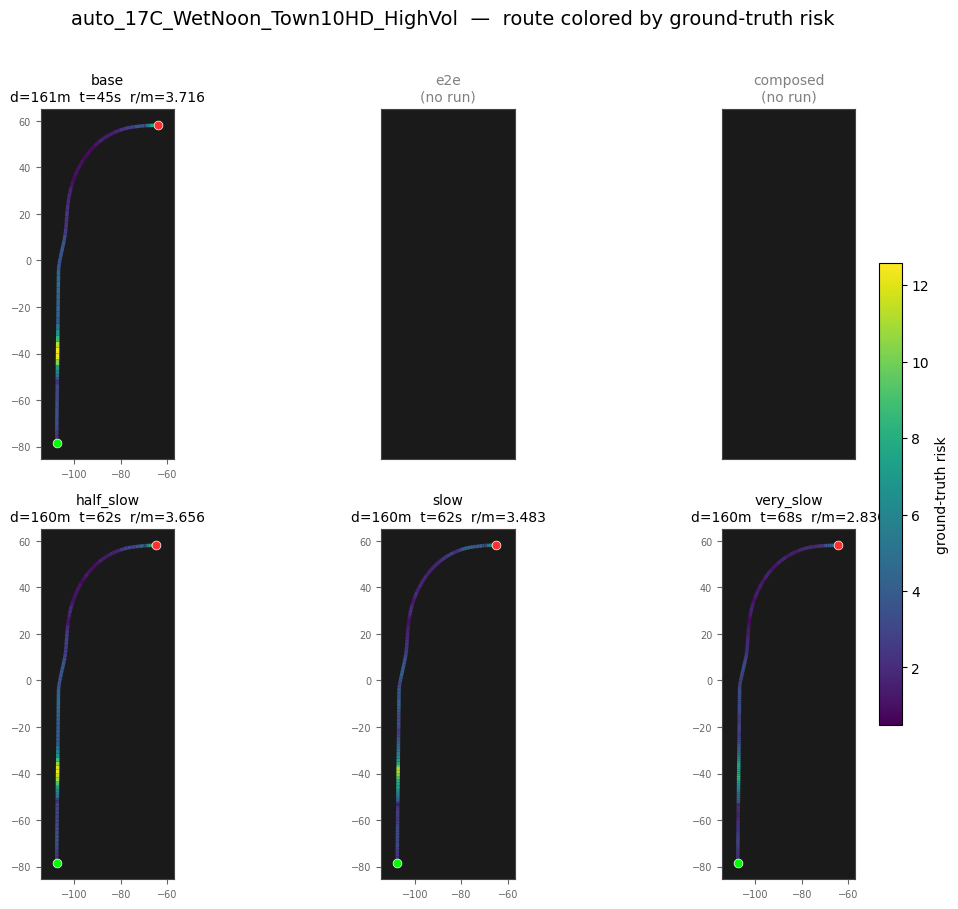

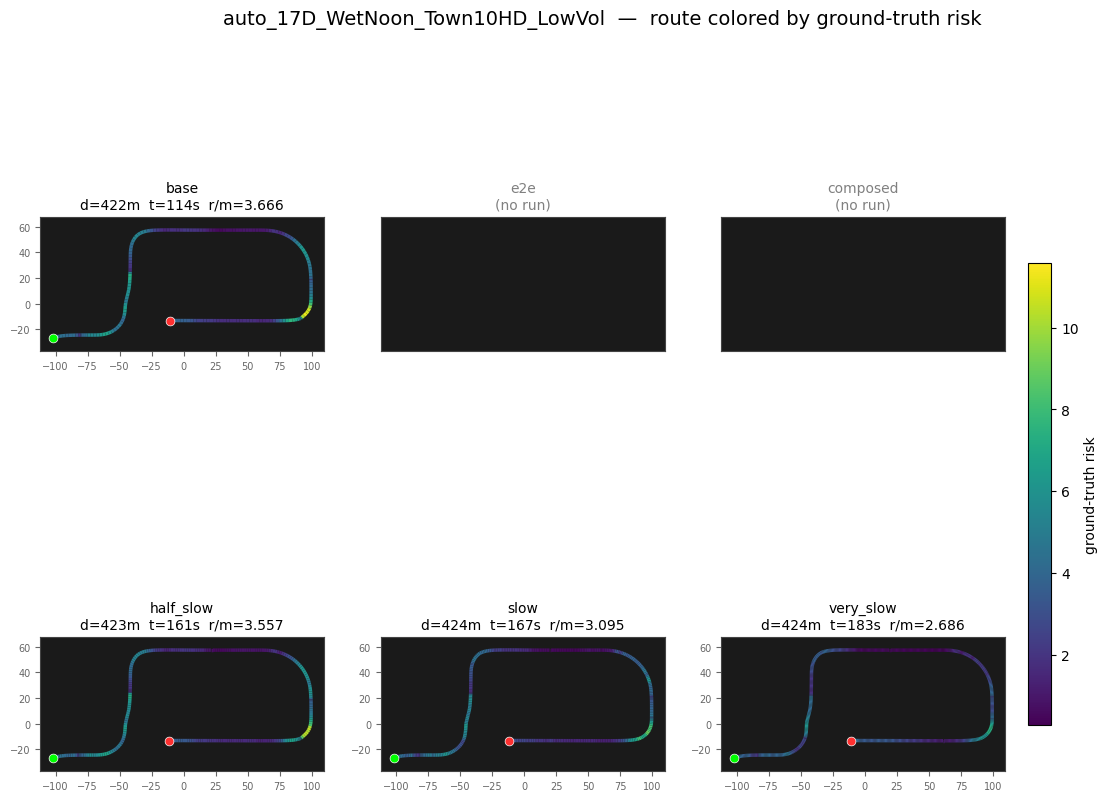

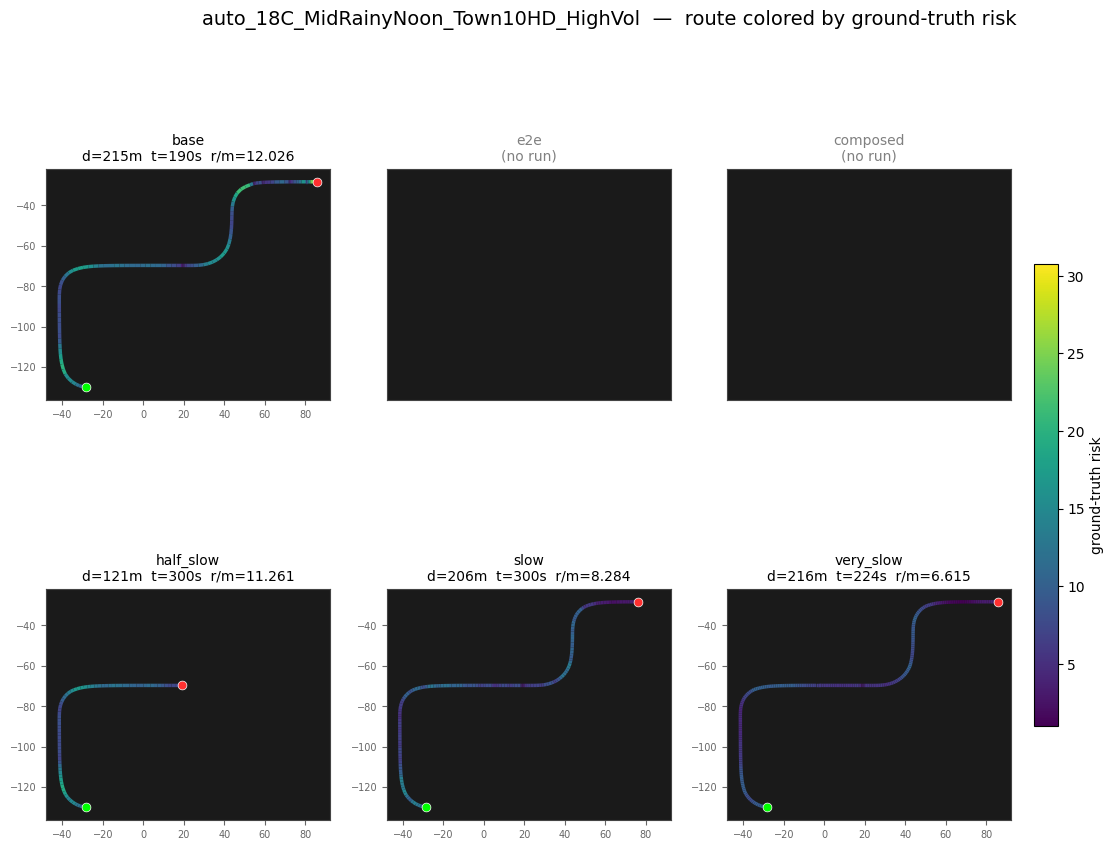

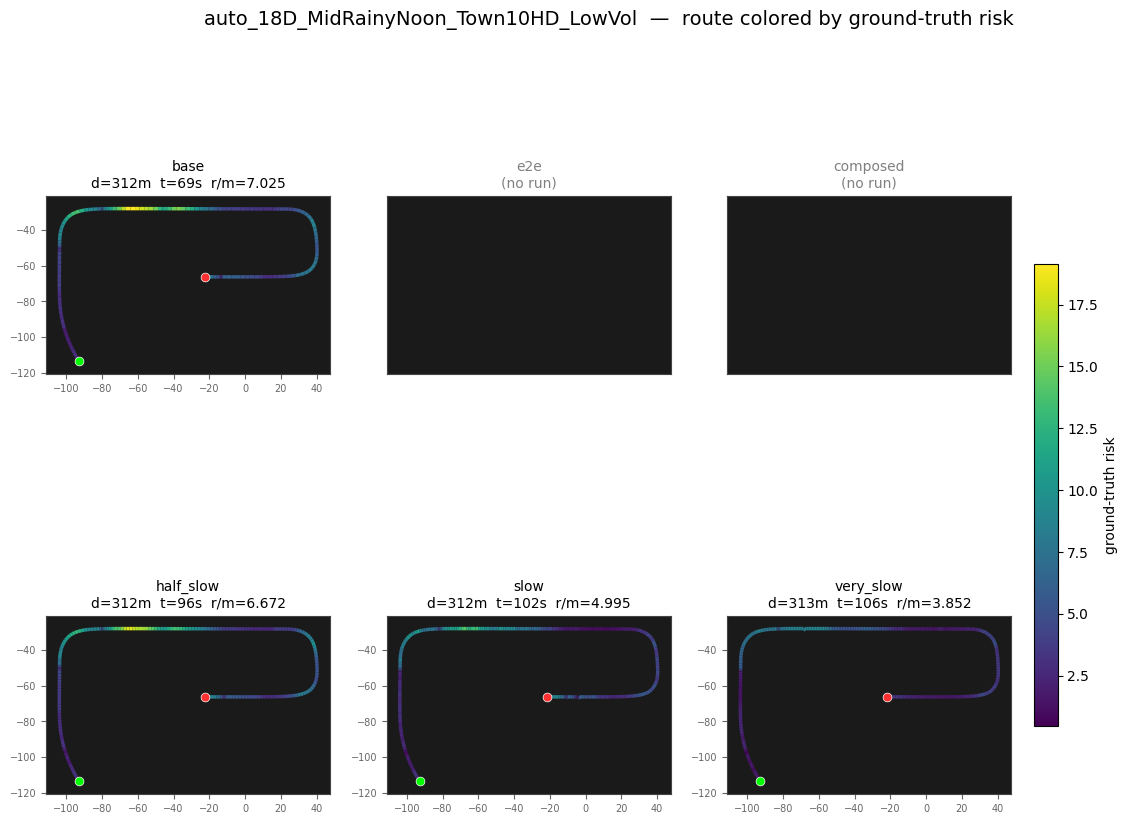

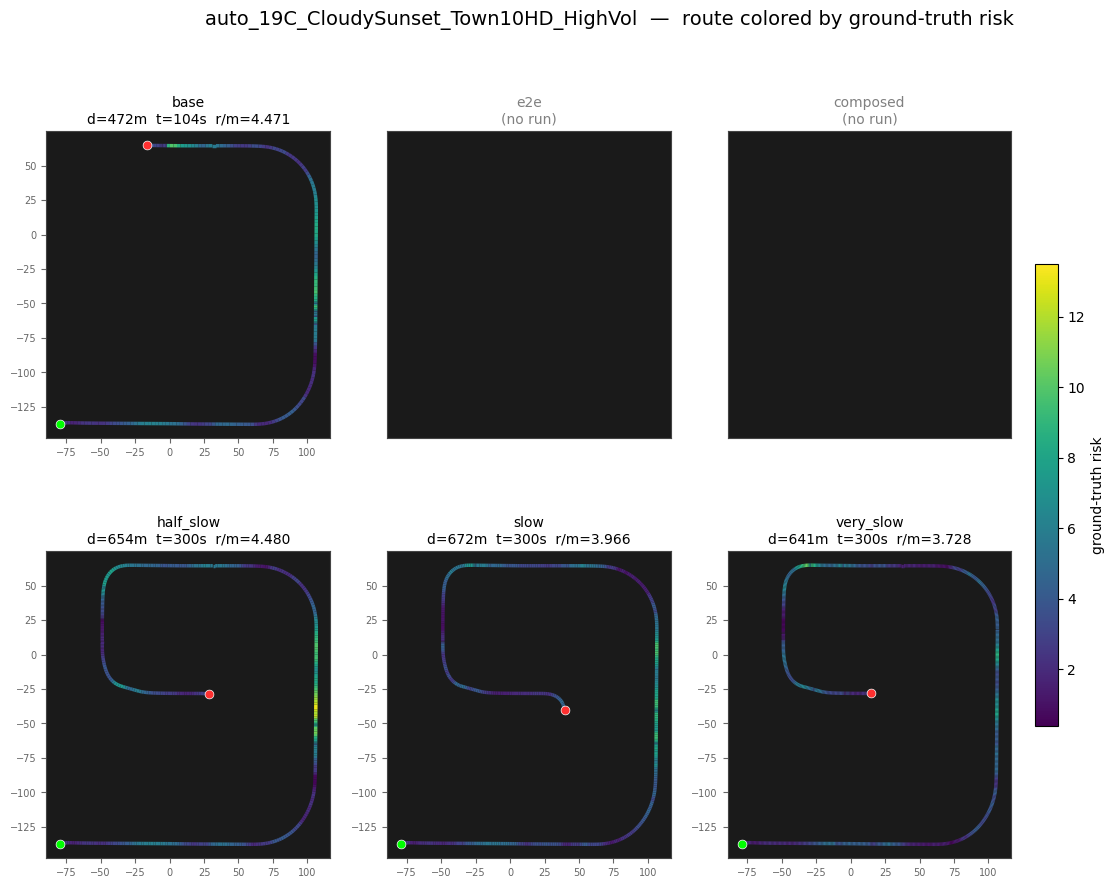

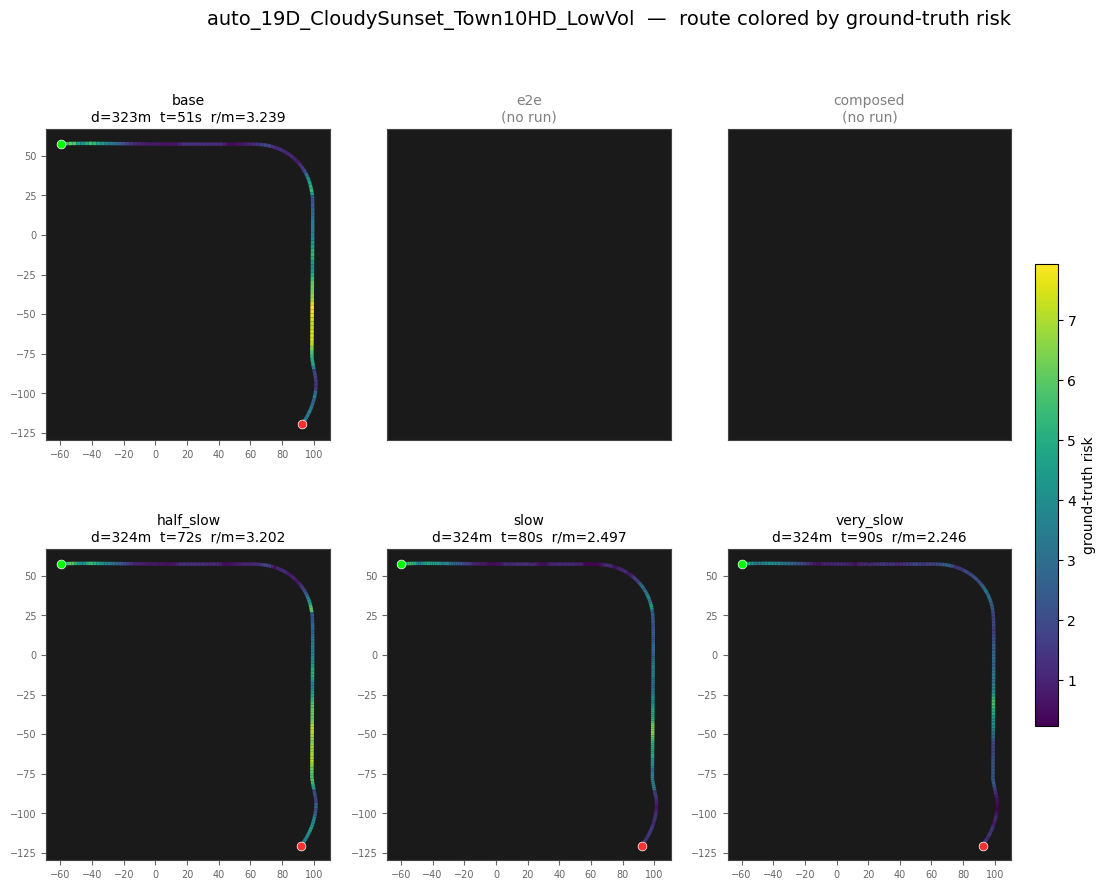

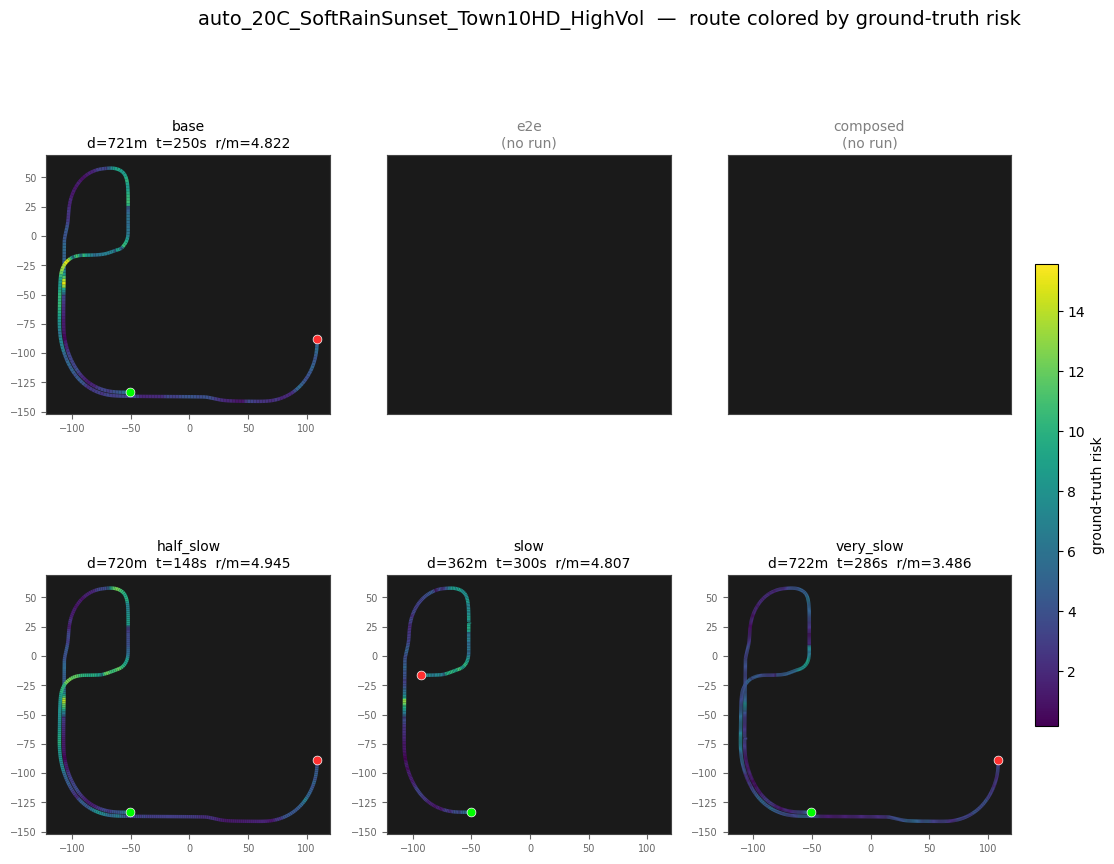

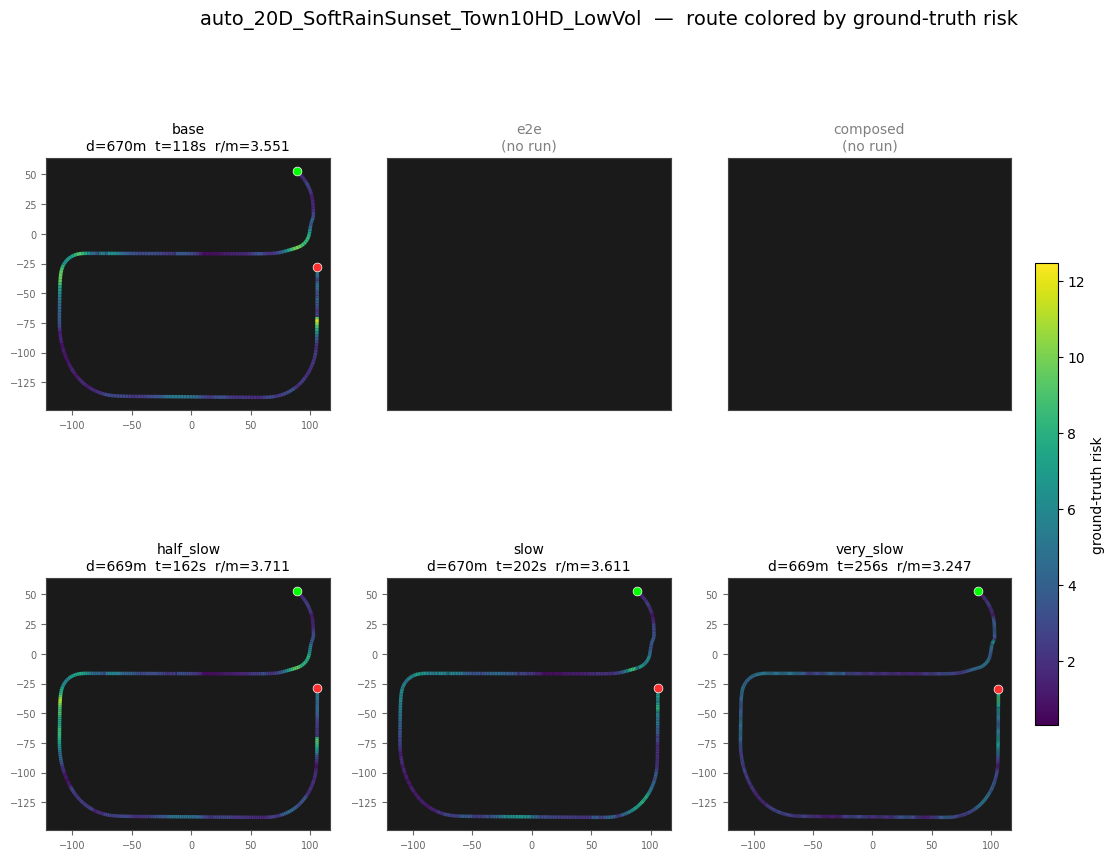

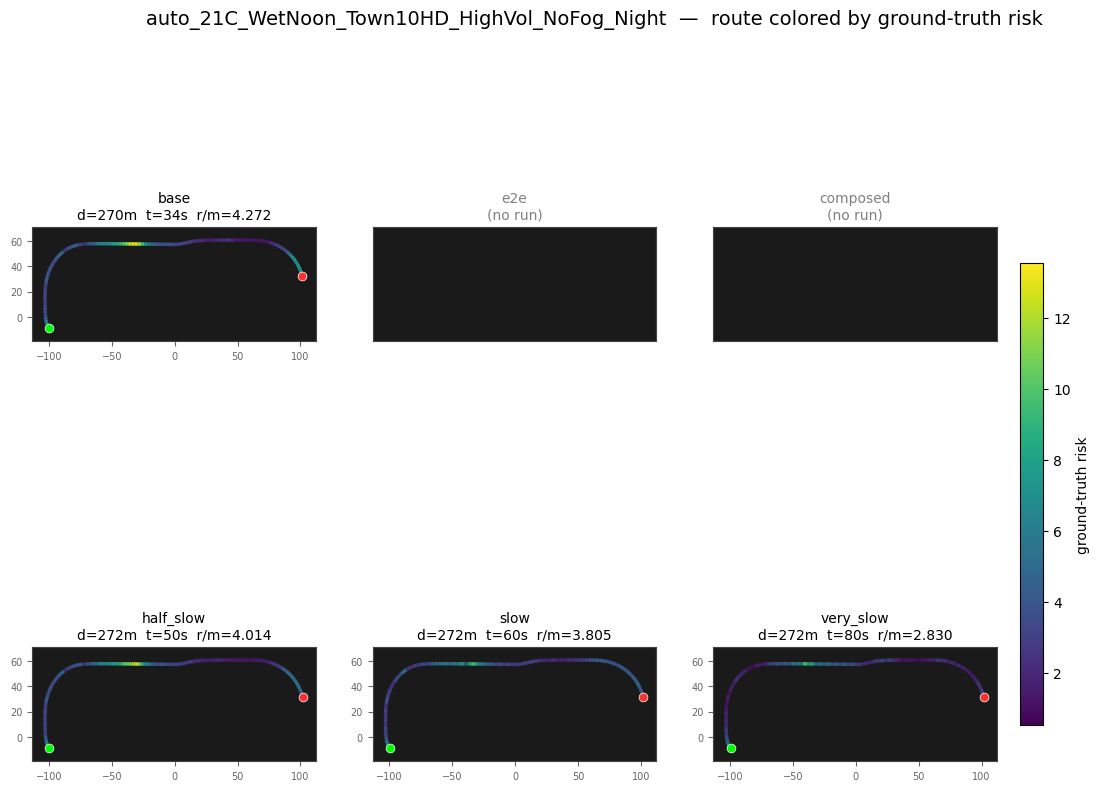

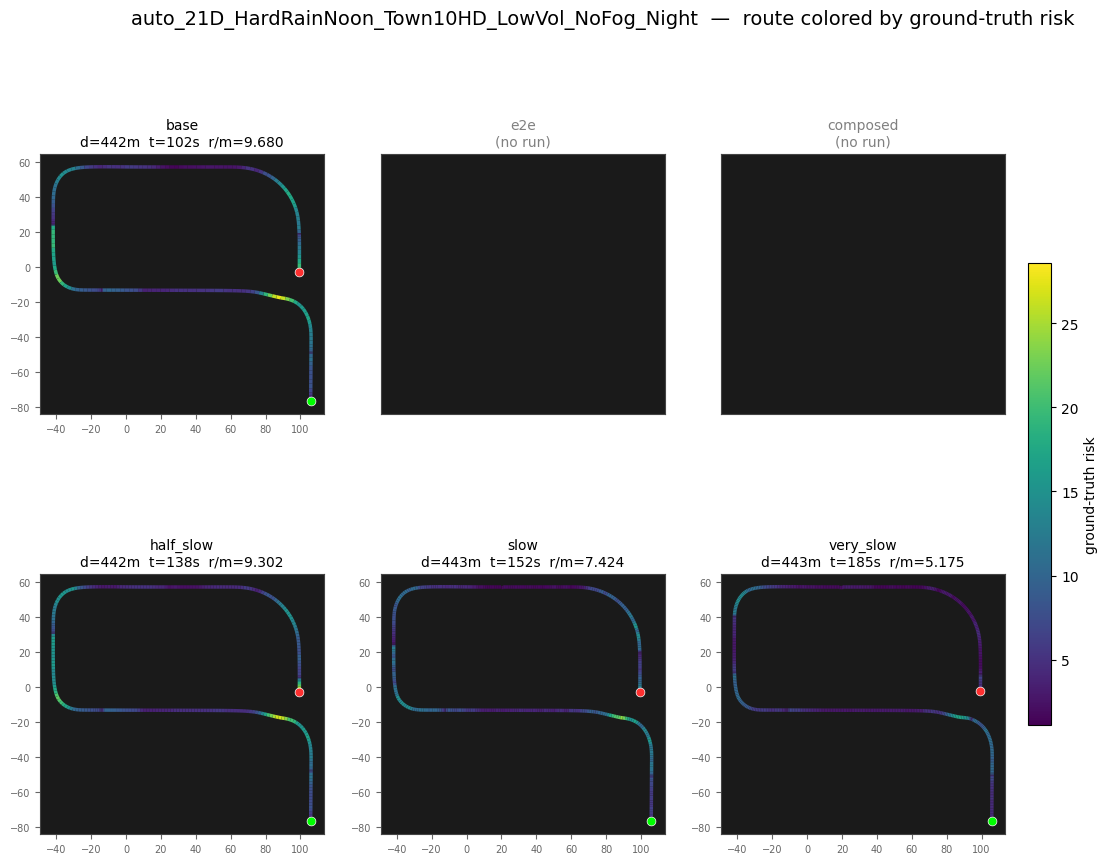

Saved route_by_risk.png for 10 trial(s).


In [6]:
import matplotlib.pyplot as plt

for tdir in selected_trial_dirs:
    cmp_dir = tdir / 'comparison'
    cmp_dir.mkdir(parents=True, exist_ok=True)
    fig = render_route_grid(
        runs_by_trial[tdir.name],
        color_by='risk_gt',
        title=f'{tdir.name}  —  route colored by ground-truth risk',
        output_path=cmp_dir / 'route_by_risk.png',
        cmap_name='viridis',
    )
    plt.show()
    plt.close(fig)
print(f'Saved route_by_risk.png for {len(selected_trial_dirs)} trial(s).')

## 6 — Route Plots Colored by Ego Speed
Same 2×3 layout but colored by the actual ego speed (`ego.speed * 3.6` km/h). This makes it easy to spot where each policy slows down: slow / half_slow / very_slow should be uniformly dim, while e2e / composed should brighten in low-risk zones and dim in dense traffic. Saved to `<trial>/comparison/route_by_speed.png`.

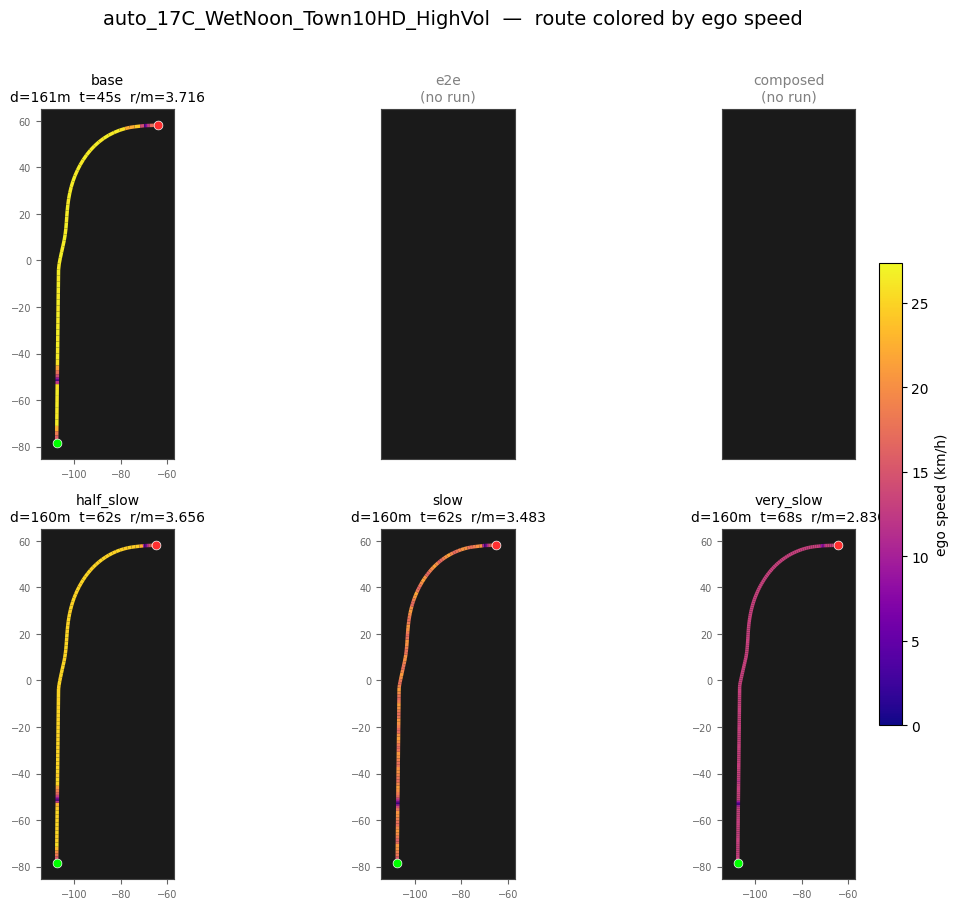

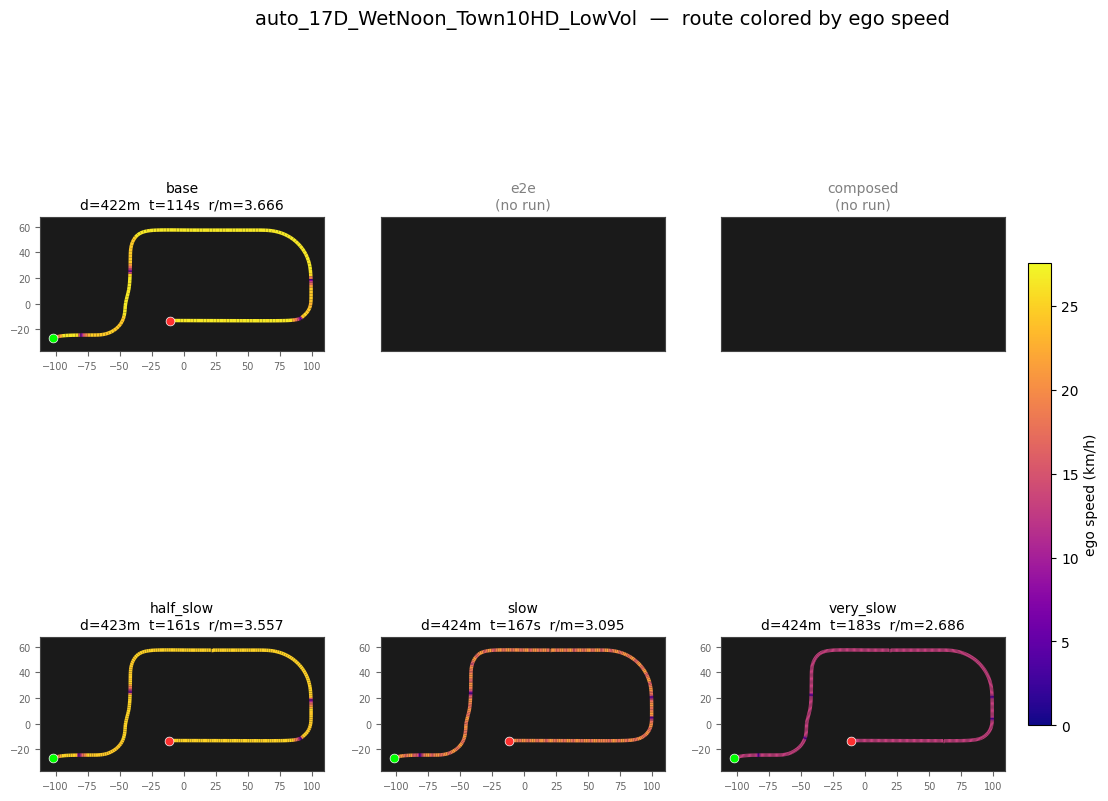

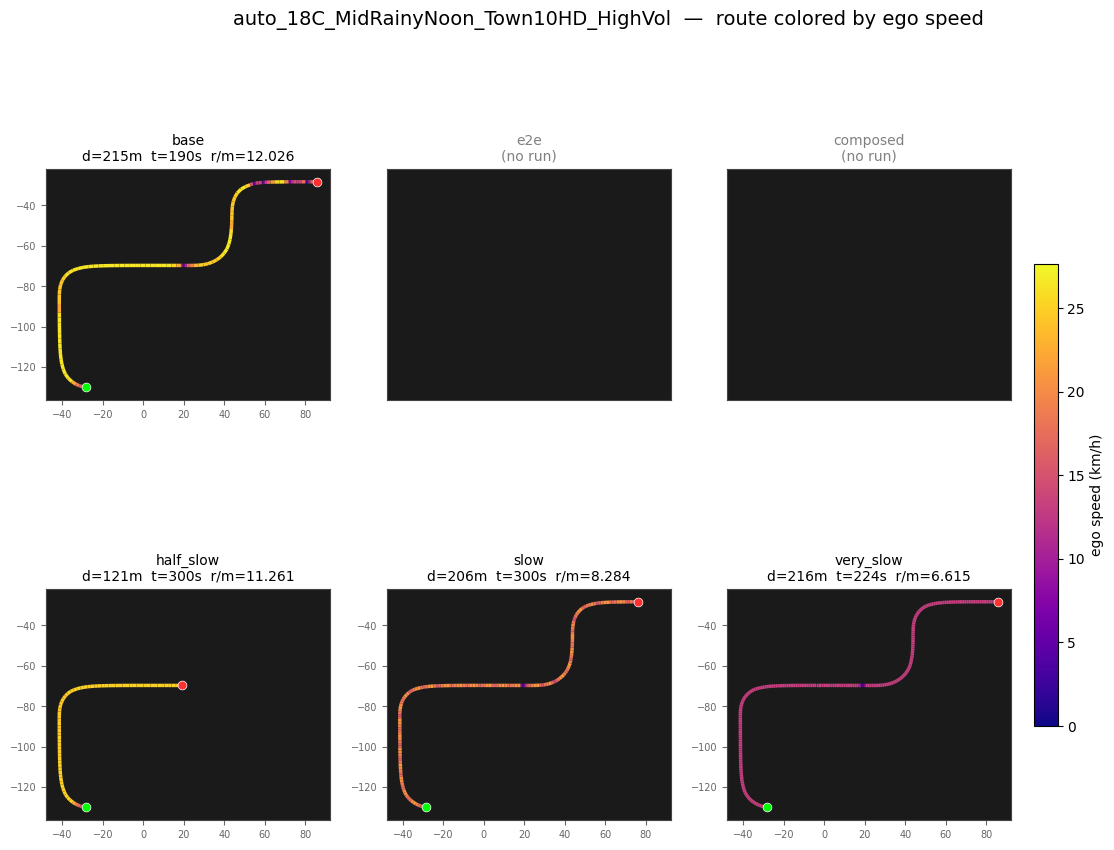

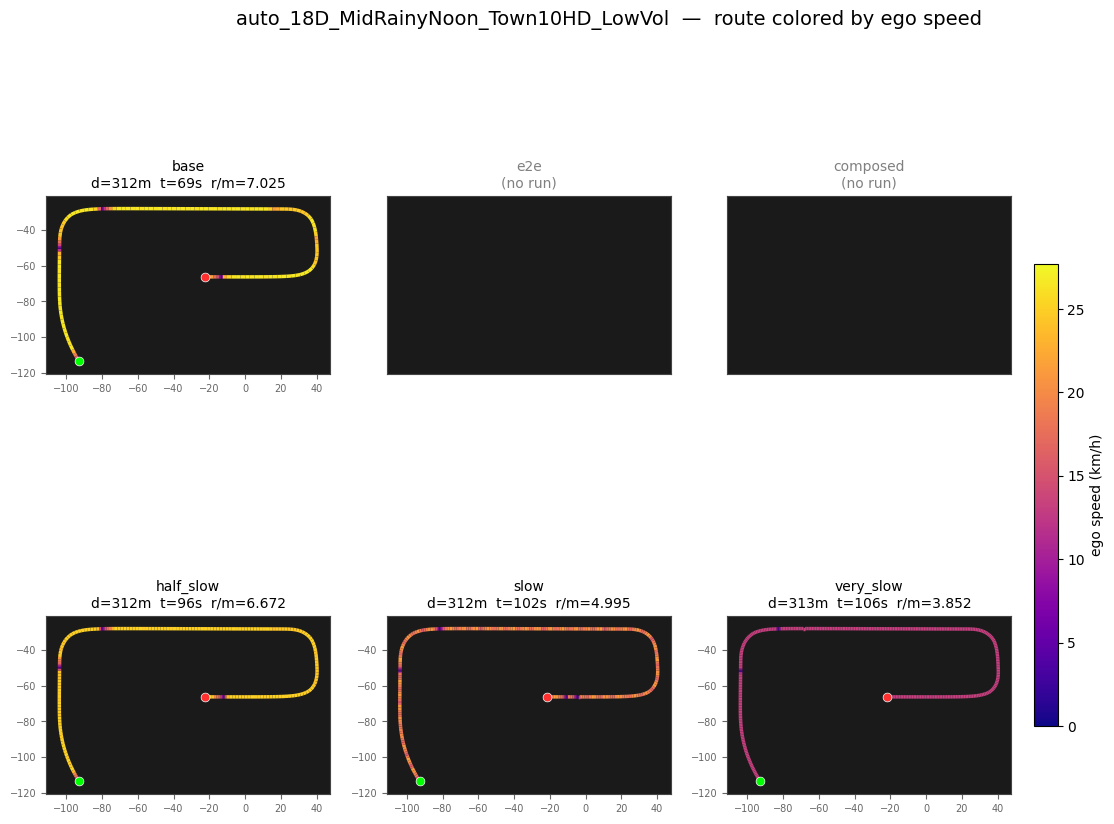

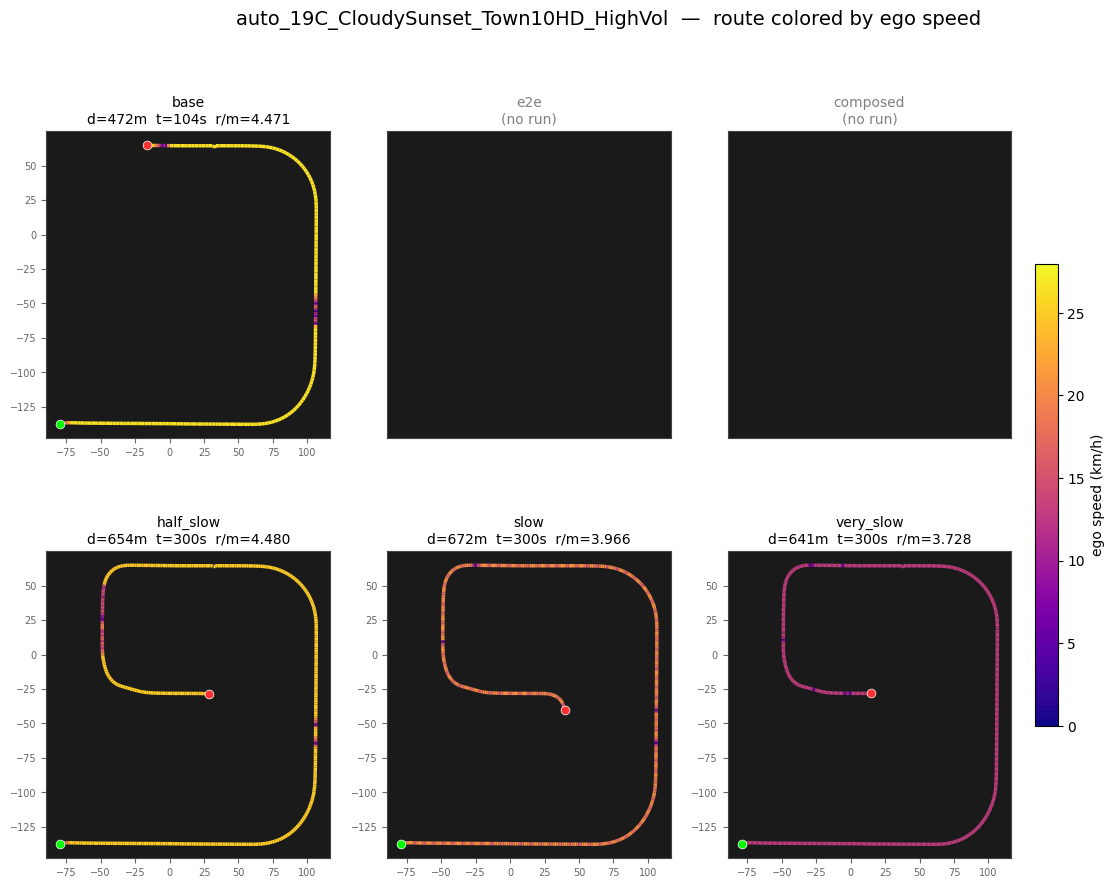

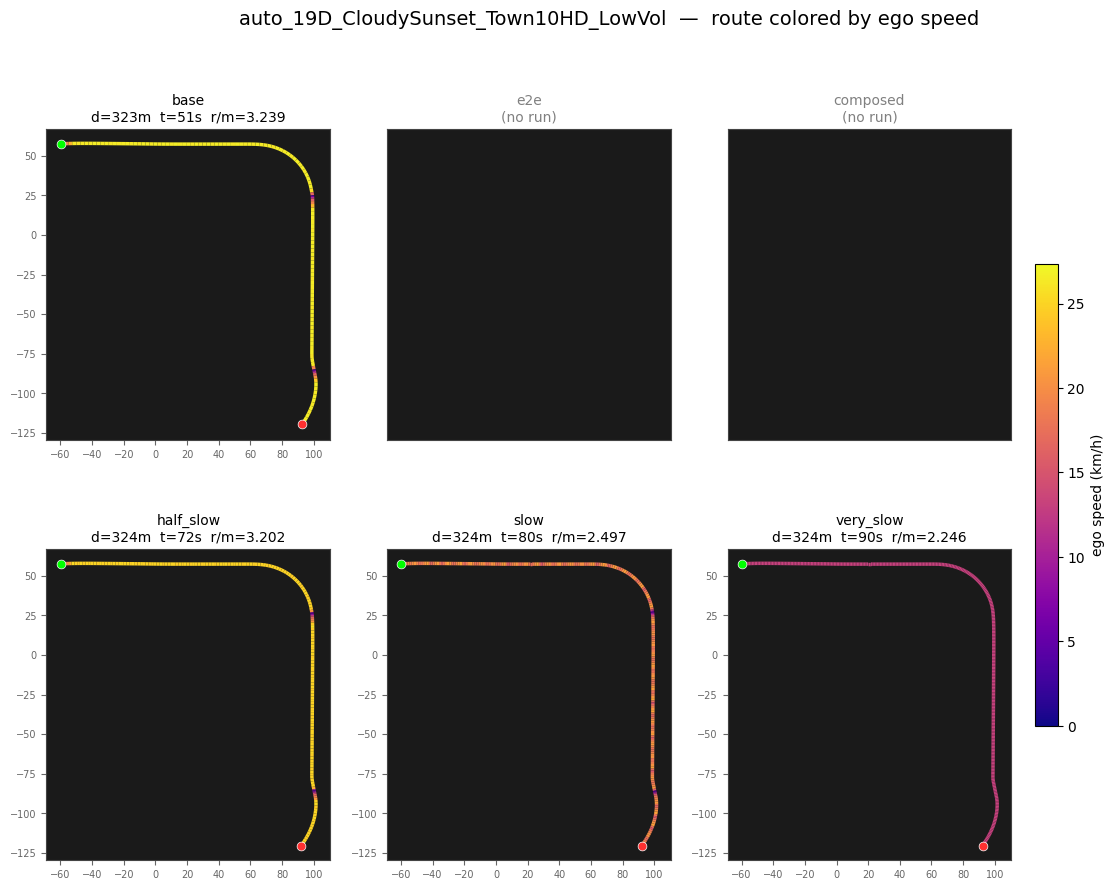

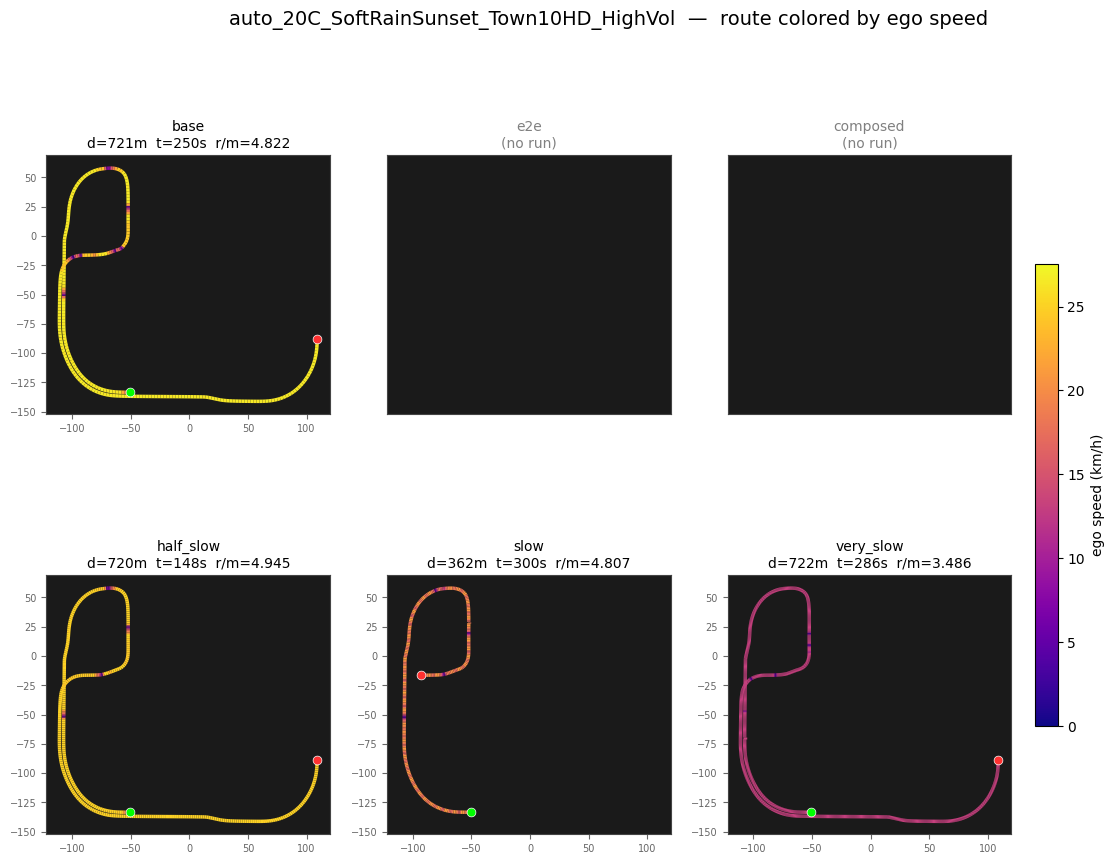

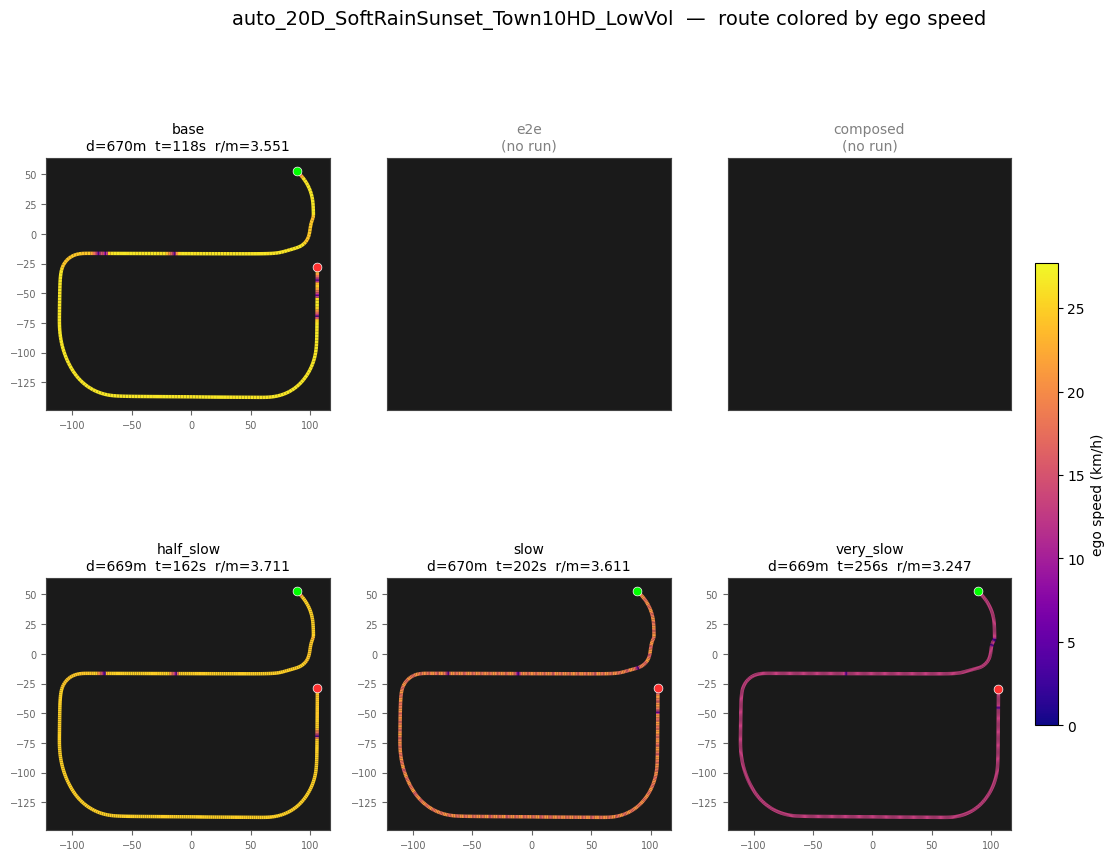

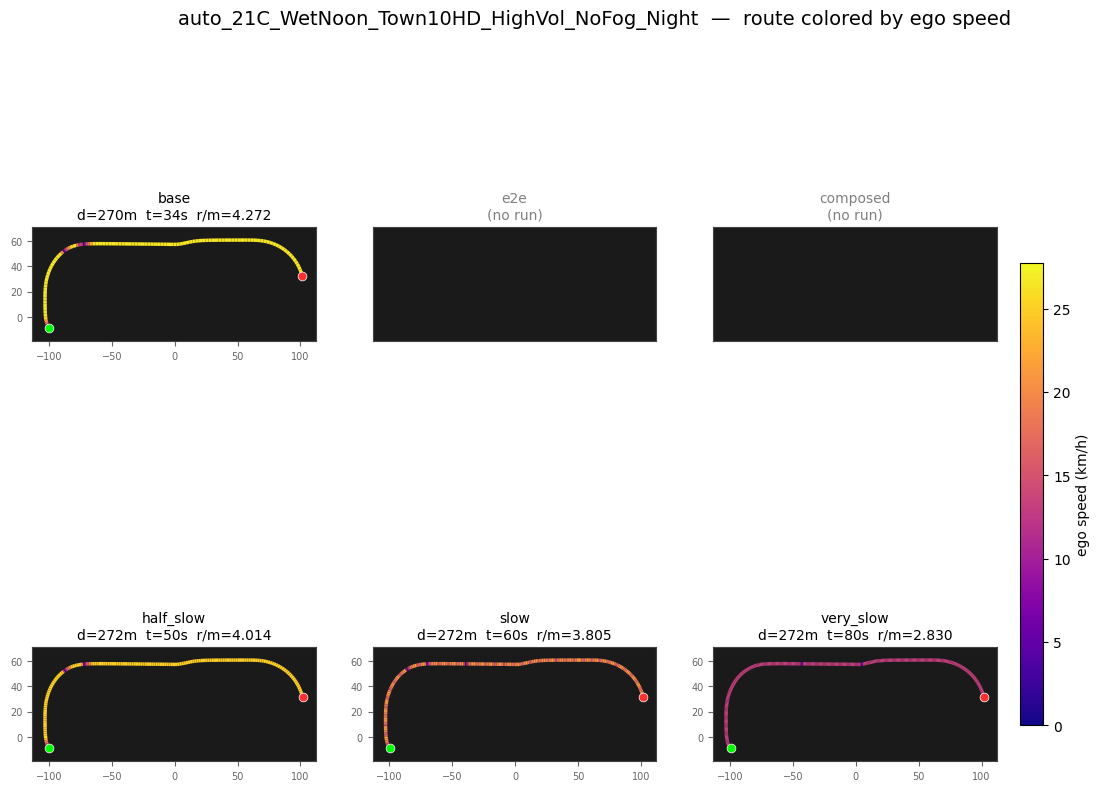

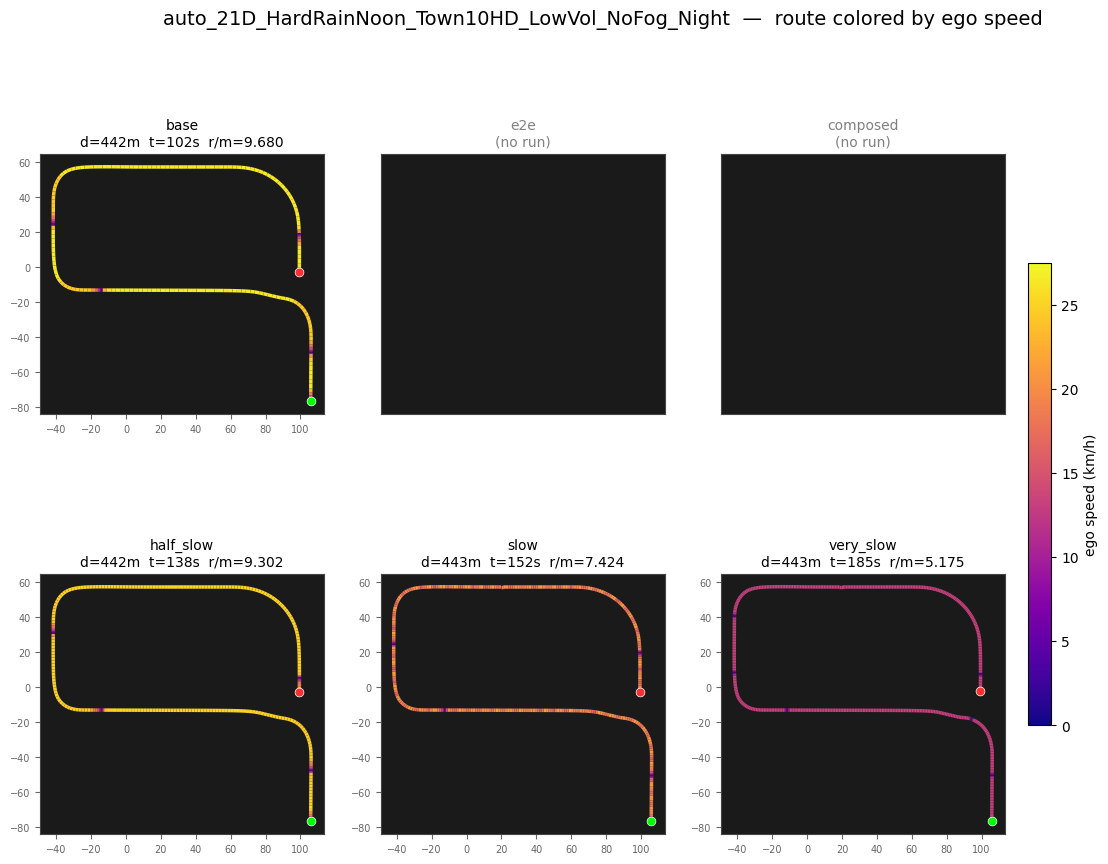

Saved route_by_speed.png for 10 trial(s).


In [7]:
for tdir in selected_trial_dirs:
    cmp_dir = tdir / 'comparison'
    cmp_dir.mkdir(parents=True, exist_ok=True)
    fig = render_route_grid(
        runs_by_trial[tdir.name],
        color_by='speed_kmh',
        title=f'{tdir.name}  —  route colored by ego speed',
        output_path=cmp_dir / 'route_by_speed.png',
        cmap_name='plasma',
    )
    plt.show()
    plt.close(fig)
print(f'Saved route_by_speed.png for {len(selected_trial_dirs)} trial(s).')

## 7 — Efficiency Bar Charts

For each trial: a 3-panel bar chart comparing every prefix to the **base** run.

| Panel | Y-axis | Interpretation |
|-------|--------|----------------|
| Δ risk/m | `prefix.risk_per_meter − base.risk_per_meter` | Negative = safer than base |
| Δ time (s) | `prefix.total_sim_time_s − base.total_sim_time_s` | Positive = route took longer |
| Efficiency | `Δ risk/m ÷ Δ time (s)` | Risk reduction per extra second; negative = efficient risk reduction |

Green bars indicate improvement (less risk / better efficiency); red bars indicate worsening. Prefixes where `|Δ time| < 0.1 s` are skipped in the efficiency panel (essentially same time as base). Saved to `<trial>/comparison/efficiency.png`.

In [ ]:
for tdir in selected_trial_dirs:
    cmp_dir = tdir / 'comparison'
    cmp_dir.mkdir(parents=True, exist_ok=True)
    fig = render_efficiency_barplot(
        runs_by_trial[tdir.name],
        title=f'{tdir.name}  —  efficiency vs. base',
        output_path=cmp_dir / 'efficiency.png',
    )
    plt.show()
    plt.close(fig)
print(f'Saved efficiency.png for {len(selected_trial_dirs)} trial(s).')

## 8 — Comparison Videos (3×3 grid)
For each trial, an MP4 with one panel per run. Every panel shows the route colored by ground-truth risk + a moving white dot at the ego's current position. Runs are synced by **route-progress fraction**, so every panel hits 100 % at the same video frame even though the runs took different sim times — the actual sim time + risk-per-meter are shown in each panel's subtitle for reference.

Toggle `RENDER_VIDEOS` to skip this step when iterating on tables / plots.

auto_17C_WetNoon_Town10HD_HighVol                       -> t:\TFG\MIREIA\trials\auto_17C_WetNoon_Town10HD_HighVol\comparison\comparison_video.mp4
auto_17D_WetNoon_Town10HD_LowVol                        -> t:\TFG\MIREIA\trials\auto_17D_WetNoon_Town10HD_LowVol\comparison\comparison_video.mp4
auto_18C_MidRainyNoon_Town10HD_HighVol                  -> t:\TFG\MIREIA\trials\auto_18C_MidRainyNoon_Town10HD_HighVol\comparison\comparison_video.mp4


KeyboardInterrupt: 

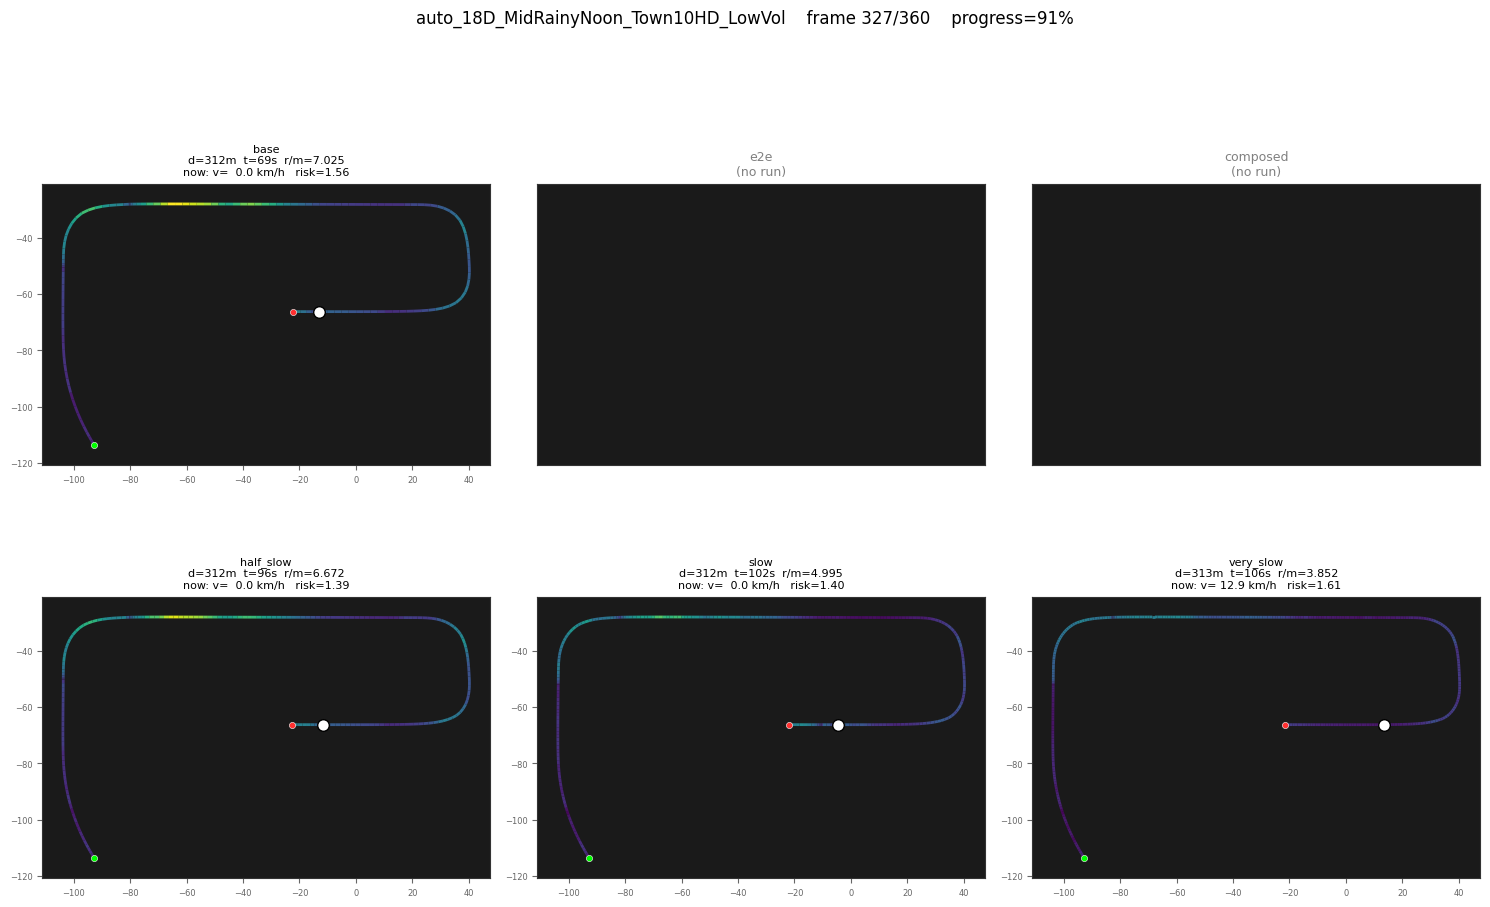

In [8]:
RENDER_VIDEOS = True          # set False if you only want the tables / static plots
VIDEO_FPS     = 8
VIDEO_SECONDS = None          # None = auto-scale to longest run (clamped 8–45s)

comparison_videos: dict[str, Path] = {}

if not RENDER_VIDEOS:
    print('RENDER_VIDEOS=False — skipping video generation.')
else:
    for tdir in selected_trial_dirs:
        cmp_dir = tdir / 'comparison'
        cmp_dir.mkdir(parents=True, exist_ok=True)
        out_path = cmp_dir / 'comparison_video.mp4'
        path = render_comparison_video(
            runs_by_trial[tdir.name],
            output_path=out_path,
            fps=VIDEO_FPS,
            video_seconds=VIDEO_SECONDS,
            title=tdir.name,
            color_by='risk_gt',
            cmap_name='viridis',
        )
        if path is None:
            print(f'{tdir.name:55s} skipped (no run has data)')
            continue
        comparison_videos[tdir.name] = path
        print(f'{tdir.name:55s} -> {path}')

# Preview the first video inline (if any).
if comparison_videos:
    first_name, first_path = next(iter(comparison_videos.items()))
    print(f'\nPreview: {first_name}')
    display(Video(str(first_path), embed=True))

## 9 — Artifact Index
Quick listing of everything this notebook produced. Re-run section 8 with `RENDER_VIDEOS=False` if you only need the tables/plots; everything else is cheap.

In [ ]:
for tdir in selected_trial_dirs:
    cmp_dir = tdir / 'comparison'
    artifacts = sorted(cmp_dir.iterdir()) if cmp_dir.exists() else []
    print(f'{tdir.name}')
    for a in artifacts:
        size_kb = a.stat().st_size / 1024.0
        print(f'  {a.name:40s}  {size_kb:8.1f} KB')

print()
print(f'Combined CSV: {trials_root / "comparison_summary.csv"}')